# EvoFormer + Decision Field
## Kompletny przykład: generator danych, trening, ewolucja i wizualizacja pola decyzyjnego

Ten notebook pokazuje hybrydowy system:
1. **Generator danych** tworzy syntetyczny problem decyzji wielokryterialnej.
2. **Transformer** uczy się relacji między cechami.
3. **Decision Field** modeluje decyzję przez prototypy, atrakcyjność i ryzyko.
4. **Algorytm ewolucyjny** stroi architekturę i hiperparametry.
5. **Wizualizacja** pokazuje przestrzeń embeddingów oraz prototypy decyzyjne.

Notebook został przygotowany jako przykład dydaktyczny do zajęć z algorytmów ewolucyjnych i neuroewolucji.

In [5]:
# =========================
# IMPORTY
# =========================
import math
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## 1. Generator danych

Tworzymy problem **selekcji kandydatów do projektu AI**.  
Każdy kandydat ma zestaw cech liczbowych z zakresu 0-10 oraz kilka ukrytych zależności nieliniowych.

Klasa docelowa:
- `0` = **reject**
- `1` = **safe**
- `2` = **high_potential**

Etykieta nie jest banalnym progiem. Powstaje z kombinacji:
- kompetencji technicznych,
- dopasowania interpersonalnego,
- kosztu,
- ryzyka,
- bonusów synergii i kar konfliktu.

In [6]:
# =========================
# GENERATOR DANYCH
# =========================
FEATURES = [
    "tech",
    "communication",
    "cost_efficiency",
    "availability",
    "fit",
    "leadership",
    "stress_resistance",
    "domain_knowledge",
    "creativity",
    "learning_speed"
]

CLASS_NAMES = {
    0: "reject",
    1: "safe",
    2: "high_potential"
}

def clamp(x, lo=0.0, hi=10.0):
    return max(lo, min(hi, x))

def make_candidate():
    # bazowe cechy
    tech = np.random.normal(6.5, 1.8)
    communication = np.random.normal(5.8, 1.9)
    cost_efficiency = np.random.normal(5.5, 2.0)
    availability = np.random.normal(6.0, 2.2)
    fit = np.random.normal(5.8, 1.8)
    leadership = np.random.normal(5.2, 2.0)
    stress_resistance = np.random.normal(5.7, 2.0)
    domain_knowledge = np.random.normal(5.8, 2.1)
    creativity = np.random.normal(5.9, 1.9)
    learning_speed = np.random.normal(6.0, 1.7)

    # ukryte korelacje i nieliniowości
    if tech > 7.5:
        learning_speed += np.random.uniform(0.2, 1.0)
    if communication > 7:
        fit += np.random.uniform(0.1, 0.8)
    if leadership > 7 and stress_resistance > 6:
        communication += np.random.uniform(0.1, 0.7)
    if cost_efficiency < 3.5:
        availability += np.random.uniform(-0.6, 0.2)

    vals = [tech, communication, cost_efficiency, availability, fit,
            leadership, stress_resistance, domain_knowledge, creativity, learning_speed]
    vals = [clamp(v) for v in vals]

    candidate = dict(zip(FEATURES, vals))

    # score główny
    synergy = 0.0
    synergy += 0.9 if candidate["tech"] > 7 and candidate["domain_knowledge"] > 7 else 0.0
    synergy += 0.8 if candidate["communication"] > 7 and candidate["fit"] > 7 else 0.0
    synergy += 0.7 if candidate["learning_speed"] > 7 and candidate["creativity"] > 7 else 0.0
    synergy += 0.5 if candidate["leadership"] > 7 and candidate["stress_resistance"] > 7 else 0.0

    conflict = 0.0
    conflict += 1.0 if candidate["tech"] > 8 and candidate["communication"] < 4 else 0.0
    conflict += 0.8 if candidate["leadership"] > 8 and candidate["fit"] < 4.5 else 0.0
    conflict += 0.9 if candidate["availability"] < 3 and candidate["domain_knowledge"] < 4 else 0.0

    potential = (
        0.22 * candidate["tech"] +
        0.10 * candidate["communication"] +
        0.10 * candidate["cost_efficiency"] +
        0.08 * candidate["availability"] +
        0.12 * candidate["fit"] +
        0.08 * candidate["leadership"] +
        0.10 * candidate["stress_resistance"] +
        0.08 * candidate["domain_knowledge"] +
        0.06 * candidate["creativity"] +
        0.06 * candidate["learning_speed"] +
        synergy - conflict
    )

    # ryzyko
    risk = 0.0
    risk += max(0, 6 - candidate["communication"]) * 0.12
    risk += max(0, 5 - candidate["stress_resistance"]) * 0.14
    risk += max(0, 4 - candidate["fit"]) * 0.10
    risk += 0.30 if candidate["tech"] > 8.5 and candidate["communication"] < 4.5 else 0.0
    risk += 0.25 if candidate["creativity"] > 8 and candidate["fit"] < 4.5 else 0.0

    # logika etykiety
    if potential >= 7.15 and risk < 0.90:
        label = 2
    elif potential >= 5.75 and risk < 1.55:
        label = 1
    else:
        label = 0

    candidate["latent_potential_score"] = round(potential, 3)
    candidate["latent_risk_score"] = round(risk, 3)
    candidate["target"] = label
    return candidate

def generate_dataset(n=2400):
    data = [make_candidate() for _ in range(n)]
    return pd.DataFrame(data)

df = generate_dataset(2400)
df.head()

,tech,communication,cost_efficiency,availability,fit,leadership,stress_resistance,domain_knowledge,creativity,learning_speed,latent_potential_score,latent_risk_score,target
0,7.394085,5.537298,6.795377,9.350666,5.378524,4.731726,8.858426,7.411613,5.007999,6.922352,7.727,0.056,2
1,5.665848,4.915113,5.983925,1.790783,2.695148,4.075425,3.674338,6.459919,4.174754,3.599084,4.480,0.446,0
2,9.138168,5.371025,5.635056,2.865554,4.820111,5.421845,3.398013,6.588966,4.758786,6.251507,5.880,0.300,1
3,4.661206,5.492665,4.432702,5.987839,5.386989,5.978698,3.169762,8.093184,10.000000,8.029188,6.368,0.317,1
4,6.893549,7.475346,3.481829,1.976393,7.854199,4.123717,3.006644,3.950758,3.751951,6.228529,5.158,0.279,0


In [7]:
print(df["target"].value_counts().sort_index())
print()
print(df.groupby("target")[FEATURES].mean().round(2))

target
0     913
1    1149
2     338
Name: count, dtype: int64

        tech  communication  cost_efficiency  availability   fit  leadership  \
target                                                                         
0       5.56           5.19             5.09          5.43  5.27        4.87   
1       6.83           6.04             5.72          6.24  6.17        5.29   
2       7.79           6.90             6.10          6.39  7.15        5.67   

        stress_resistance  domain_knowledge  creativity  learning_speed  
target                                                                   
0                    5.13              5.36        5.50            5.69  
1                    5.85              5.81        6.02            6.30  
2                    6.40              6.80        6.46            6.81  


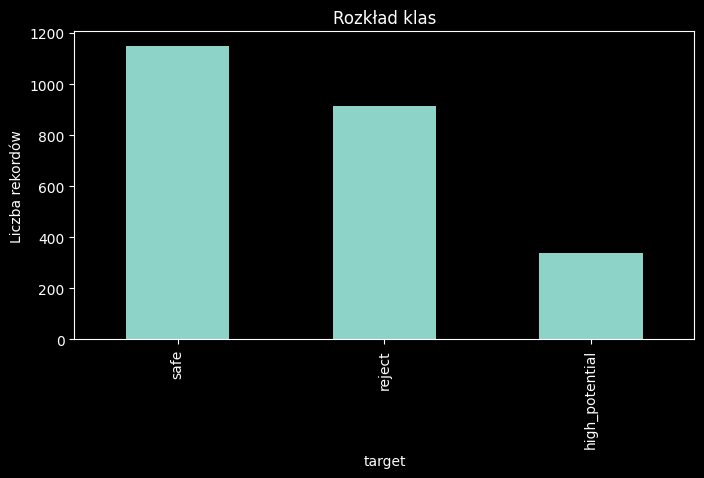

In [8]:
# szybki rzut oka na rozkład klas
ax = df["target"].map(CLASS_NAMES).value_counts().plot(kind="bar", figsize=(8,4))
ax.set_title("Rozkład klas")
ax.set_ylabel("Liczba rekordów")
plt.show()

## 2. Przygotowanie danych

In [9]:
X = df[FEATURES].values.astype(np.float32)
y = df["target"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

train: (1680, 10) (1680,)
val:   (360, 10) (360,)
test:  (360, 10) (360,)


In [11]:
class CandidateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = CandidateDataset(X_train, y_train)
val_ds = CandidateDataset(X_val, y_val)
test_ds = CandidateDataset(X_test, y_test)

## 3. Model: Transformer + Decision Field

### Tokenizacja cech
Każda cecha jest traktowana jako osobny token:
- mamy wartość cechy,
- mamy embedding typu cechy,
- transformer uczy się zależności między cechami.

### Decision Field
Zamiast klasycznej warstwy liniowej mamy:
- prototypy dla każdej klasy,
- atrakcyjność zależną od odległości od prototypów,
- głowę ryzyka,
- logits zbudowane z przyciągania i ryzyka.

In [12]:
# =========================
# MODEL
# =========================
class FeatureTokenizer(nn.Module):
    def __init__(self, num_features, d_model):
        super().__init__()
        self.feature_embed = nn.Embedding(num_features, d_model)
        self.value_proj = nn.Linear(1, d_model)

    def forward(self, x):
        # x: [batch, num_features]
        b, f = x.shape
        value_tokens = self.value_proj(x.unsqueeze(-1))   # [b, f, d]
        ids = torch.arange(f, device=x.device).unsqueeze(0).repeat(b, 1)
        feature_tokens = self.feature_embed(ids)          # [b, f, d]
        return value_tokens + feature_tokens

class EvoFormer(nn.Module):
    def __init__(self, num_features, d_model=32, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.proj = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)
        enc = self.encoder(tokens)
        pooled = enc.mean(dim=1)
        z = self.proj(pooled)
        return z

class DecisionField(nn.Module):
    def __init__(self, embedding_dim, num_classes, proto_count=3, temperature=1.0, risk_weight=0.35):
        super().__init__()
        self.num_classes = num_classes
        self.proto_count = proto_count
        self.temperature = temperature
        self.risk_weight = risk_weight

        self.prototypes = nn.Parameter(
            torch.randn(num_classes, proto_count, embedding_dim) * 0.5
        )
        self.risk_head = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.GELU(),
            nn.Linear(embedding_dim // 2, 1)
        )

    def forward(self, z):
        # z: [b, d]
        z_exp = z[:, None, None, :]               # [b, 1, 1, d]
        p_exp = self.prototypes[None, :, :, :]    # [1, c, p, d]
        dist2 = ((z_exp - p_exp) ** 2).sum(dim=-1)  # [b, c, p]

        attraction = torch.exp(-dist2 / self.temperature).sum(dim=-1)  # [b, c]
        risk = torch.sigmoid(self.risk_head(z))                         # [b, 1]
        logits = attraction - self.risk_weight * risk
        return logits, risk

class HybridDecisionNet(nn.Module):
    def __init__(self, num_features, num_classes, d_model, nhead, num_layers, dropout, proto_count, temperature, risk_weight):
        super().__init__()
        self.backbone = EvoFormer(
            num_features=num_features,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        )
        self.field = DecisionField(
            embedding_dim=d_model,
            num_classes=num_classes,
            proto_count=proto_count,
            temperature=temperature,
            risk_weight=risk_weight
        )

    def forward(self, x):
        z = self.backbone(x)
        logits, risk = self.field(z)
        return logits, risk, z

## 4. Narzędzia treningowe

In [13]:
# =========================
# TRENING I EWALUACJA
# =========================
def make_loaders(batch_size, train_ds=train_ds, val_ds=val_ds, test_ds=test_ds):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

def train_one_epoch(model, loader, optimizer, alpha_risk=0.05):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits, risk, z = model(xb)
        ce = F.cross_entropy(logits, yb)
        reg = alpha_risk * risk.mean()
        loss = ce + reg
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        preds = logits.argmax(dim=1)
        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred, average="macro")
    return total_loss / len(loader.dataset), acc, f1

@torch.no_grad()
def evaluate(model, loader, alpha_risk=0.05):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits, risk, z = model(xb)
        ce = F.cross_entropy(logits, yb)
        reg = alpha_risk * risk.mean()
        loss = ce + reg

        total_loss += loss.item() * len(xb)
        preds = logits.argmax(dim=1)
        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred, average="macro")
    return total_loss / len(loader.dataset), acc, f1

@torch.no_grad()
def predict_embeddings(model, loader):
    model.eval()
    all_logits, all_risk, all_z, all_y = [], [], [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits, risk, z = model(xb)
        all_logits.append(logits.cpu())
        all_risk.append(risk.cpu())
        all_z.append(z.cpu())
        all_y.append(yb)

    logits = torch.cat(all_logits).numpy()
    risk = torch.cat(all_risk).numpy().reshape(-1)
    z = torch.cat(all_z).numpy()
    y = torch.cat(all_y).numpy()
    pred = logits.argmax(axis=1)
    return logits, risk, z, y, pred

def build_model_from_genome(genome):
    model = HybridDecisionNet(
        num_features=len(FEATURES),
        num_classes=3,
        d_model=genome["d_model"],
        nhead=genome["nhead"],
        num_layers=genome["num_layers"],
        dropout=genome["dropout"],
        proto_count=genome["proto_count"],
        temperature=genome["temperature"],
        risk_weight=genome["risk_weight"],
    )
    return model.to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5. Algorytm ewolucyjny

Genom opisuje model:
- `d_model`
- `nhead`
- `num_layers`
- `dropout`
- `lr`
- `proto_count`
- `temperature`
- `risk_weight`
- `batch_size`

Fitness uwzględnia:
- accuracy,
- F1 macro,
- rozdzielność w przestrzeni embeddingów,
- karę za złożoność.

In [15]:
# =========================
# EWOLUCJA
# =========================
SEARCH_SPACE = {
    "d_model": [16, 32, 48, 64],
    "nhead": [2, 4, 8],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2],
    "lr": [0.001, 0.002, 0.003, 0.005],
    "proto_count": [2, 3, 4],
    "temperature": [0.5, 1.0, 1.5, 2.0],
    "risk_weight": [0.15, 0.25, 0.35, 0.45],
    "batch_size": [32, 64, 96],
}

def valid_genome(g):
    return g["d_model"] % g["nhead"] == 0

def random_genome():
    while True:
        g = {k: random.choice(v) for k, v in SEARCH_SPACE.items()}
        if valid_genome(g):
            return g

def mutate(genome, mutation_rate=0.35):
    child = copy.deepcopy(genome)
    keys = list(child.keys())
    for k in keys:
        if random.random() < mutation_rate:
            child[k] = random.choice(SEARCH_SPACE[k])
    if not valid_genome(child):
        return random_genome()
    return child

def crossover(g1, g2):
    child = {}
    for k in g1.keys():
        child[k] = g1[k] if random.random() < 0.5 else g2[k]
    if not valid_genome(child):
        return random_genome()
    return child

def class_centroid_separation(z, y):
    centroids = []
    for cls in sorted(np.unique(y)):
        centroids.append(z[y == cls].mean(axis=0))
    centroids = np.array(centroids)
    dists = []
    for i in range(len(centroids)):
        for j in range(i + 1, len(centroids)):
            d = np.linalg.norm(centroids[i] - centroids[j])
            dists.append(d)
    return float(np.mean(dists)) if dists else 0.0

def fitness_score(acc, f1, separation, param_count):
    complexity_penalty = param_count / 120000.0
    return 0.50 * acc + 0.25 * f1 + 0.20 * min(separation / 5.0, 1.0) - 0.05 * complexity_penalty

def train_candidate(genome, epochs=6, verbose=False):
    train_loader, val_loader, test_loader = make_loaders(genome["batch_size"])
    model = build_model_from_genome(genome)
    optimizer = torch.optim.Adam(model.parameters(), lr=genome["lr"])

    history = []
    best_state = None
    best_val_f1 = -1.0

    for epoch in range(epochs):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_f1 = evaluate(model, val_loader)
        history.append((tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1))

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    val_logits, val_risk, val_z, val_y, val_pred = predict_embeddings(model, val_loader)

    acc = accuracy_score(val_y, val_pred)
    f1 = f1_score(val_y, val_pred, average="macro")
    separation = class_centroid_separation(val_z, val_y)
    params = count_params(model)
    fit = fitness_score(acc, f1, separation, params)

    result = {
        "genome": genome,
        "fitness": fit,
        "val_acc": acc,
        "val_f1": f1,
        "separation": separation,
        "params": params,
        "history": history,
        "state_dict": copy.deepcopy(model.state_dict())
    }
    return result

def evolutionary_search(pop_size=6, generations=4, elite_size=2, epochs_per_candidate=5):
    population = [random_genome() for _ in range(pop_size)]
    hall_of_fame = []

    for gen in range(generations):
        results = []
        print(f"\n===== GENERATION {gen + 1}/{generations} =====")
        for i, genome in enumerate(population, 1):
            res = train_candidate(genome, epochs=epochs_per_candidate)
            results.append(res)
            print(
                f"[{i}/{len(population)}] genome={genome} | "
                f"fitness={res['fitness']:.4f} | acc={res['val_acc']:.4f} | "
                f"f1={res['val_f1']:.4f} | sep={res['separation']:.3f} | params={res['params']}"
            )

        results = sorted(results, key=lambda x: x["fitness"], reverse=True)
        hall_of_fame.append(results[0])

        elites = results[:elite_size]
        next_population = [copy.deepcopy(e["genome"]) for e in elites]

        while len(next_population) < pop_size:
            p1, p2 = random.sample(elites, 2)
            child = crossover(p1["genome"], p2["genome"])
            child = mutate(child, mutation_rate=0.40)
            next_population.append(child)

        population = next_population

    best_overall = sorted(hall_of_fame, key=lambda x: x["fitness"], reverse=True)[0]
    return best_overall, hall_of_fame

## 6. Uruchomienie ewolucji

Parametry są ustawione tak, by notebook dał się uruchomić na CPU w rozsądnym czasie.  
Na mocniejszej maszynie można zwiększyć:
- `pop_size`
- `generations`
- `epochs_per_candidate`

In [16]:
best_result, hof = evolutionary_search(
    pop_size=6,
    generations=4,
    elite_size=2,
    epochs_per_candidate=5
)

print("\nNAJLEPSZY GENOM:")
print(best_result["genome"])
print("fitness:", round(best_result["fitness"], 4))
print("val_acc :", round(best_result["val_acc"], 4))
print("val_f1  :", round(best_result["val_f1"], 4))
print("sep     :", round(best_result["separation"], 4))
print("params  :", best_result["params"])


===== GENERATION 1/4 =====
[1/6] genome={'d_model': 16, 'nhead': 2, 'num_layers': 3, 'dropout': 0.1, 'lr': 0.002, 'proto_count': 2, 'temperature': 1.0, 'risk_weight': 0.15, 'batch_size': 96} | fitness=0.6165 | acc=0.8083 | f1=0.5864 | sep=1.723 | params=7681
[2/6] genome={'d_model': 16, 'nhead': 8, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.001, 'proto_count': 2, 'temperature': 1.0, 'risk_weight': 0.25, 'batch_size': 96} | fitness=0.6055 | acc=0.7972 | f1=0.5786 | sep=1.614 | params=5457
[3/6] genome={'d_model': 16, 'nhead': 8, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.005, 'proto_count': 2, 'temperature': 2.0, 'risk_weight': 0.35, 'batch_size': 32} | fitness=0.6261 | acc=0.8000 | f1=0.5803 | sep=2.059 | params=3233
[4/6] genome={'d_model': 32, 'nhead': 8, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.003, 'proto_count': 2, 'temperature': 1.0, 'risk_weight': 0.35, 'batch_size': 32} | fitness=0.2289 | acc=0.3806 | f1=0.1838 | sep=0.029 | params=20385
[5/6] genome={'d_model': 16, 'nhead': 4, 'n

## 7. Finalny model i test

Najlepszy model z ewolucji dodatkowo dociągamy jeszcze przez kilka epok.

In [19]:
best_genome = best_result["genome"]
train_loader, val_loader, test_loader = make_loaders(best_genome["batch_size"])

final_model = build_model_from_genome(best_genome)
final_model.load_state_dict(best_result["state_dict"])

optimizer = torch.optim.Adam(final_model.parameters(), lr=best_genome["lr"])

extra_epochs = 6
final_history = []

for epoch in range(extra_epochs):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(final_model, train_loader, optimizer)
    va_loss, va_acc, va_f1 = evaluate(final_model, val_loader)
    final_history.append((tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1))
    print(
        f"Fine-tuning epoch {epoch+1}/{extra_epochs} | "
        f"train_acc={tr_acc:.4f} | train_f1={tr_f1:.4f} | "
        f"val_acc={va_acc:.4f} | val_f1={va_f1:.4f}"
    )

test_loss, test_acc, test_f1 = evaluate(final_model, test_loader)
print("\nTEST:")
print("loss:", round(test_loss, 4))
print("acc :", round(test_acc, 4))
print("f1  :", round(test_f1, 4))

Fine-tuning epoch 1/6 | train_acc=0.8185 | train_f1=0.7905 | val_acc=0.8528 | val_f1=0.8151
Fine-tuning epoch 2/6 | train_acc=0.8179 | train_f1=0.7963 | val_acc=0.8583 | val_f1=0.8254
Fine-tuning epoch 3/6 | train_acc=0.8060 | train_f1=0.7898 | val_acc=0.8167 | val_f1=0.7341
Fine-tuning epoch 4/6 | train_acc=0.8250 | train_f1=0.7974 | val_acc=0.8444 | val_f1=0.8168
Fine-tuning epoch 5/6 | train_acc=0.8351 | train_f1=0.8151 | val_acc=0.8222 | val_f1=0.7756
Fine-tuning epoch 6/6 | train_acc=0.8310 | train_f1=0.8110 | val_acc=0.8194 | val_f1=0.7460

TEST:
loss: 0.5451
acc : 0.8361
f1  : 0.7858


In [20]:
test_logits, test_risk, test_z, test_y, test_pred = predict_embeddings(final_model, test_loader)

print(classification_report(test_y, test_pred, target_names=[CLASS_NAMES[i] for i in range(3)]))

                precision    recall  f1-score   support

        reject       0.84      0.96      0.89       137
          safe       0.82      0.84      0.83       173
high_potential       0.92      0.48      0.63        50

      accuracy                           0.84       360
     macro avg       0.86      0.76      0.79       360
  weighted avg       0.84      0.84      0.83       360



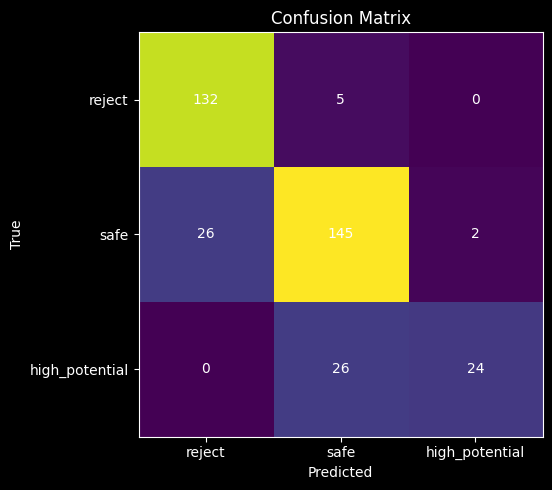

In [21]:
cm = confusion_matrix(test_y, test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(3), [CLASS_NAMES[i] for i in range(3)])
ax.set_yticks(range(3), [CLASS_NAMES[i] for i in range(3)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 8. Wizualizacja przestrzeni decyzyjnej

### Co pokazujemy?
1. Embeddingi kandydatów po PCA do 2D
2. Prototypy Decision Field
3. Tło pola decyzyjnego w uproszczonej postaci 2D

Uwaga: pole w tle jest wizualizacją interpretacyjną w przestrzeni PCA, a nie dokładnym odtworzeniem pełnego modelu w wymiarze oryginalnym. Dydaktycznie sprawdza się bardzo dobrze.

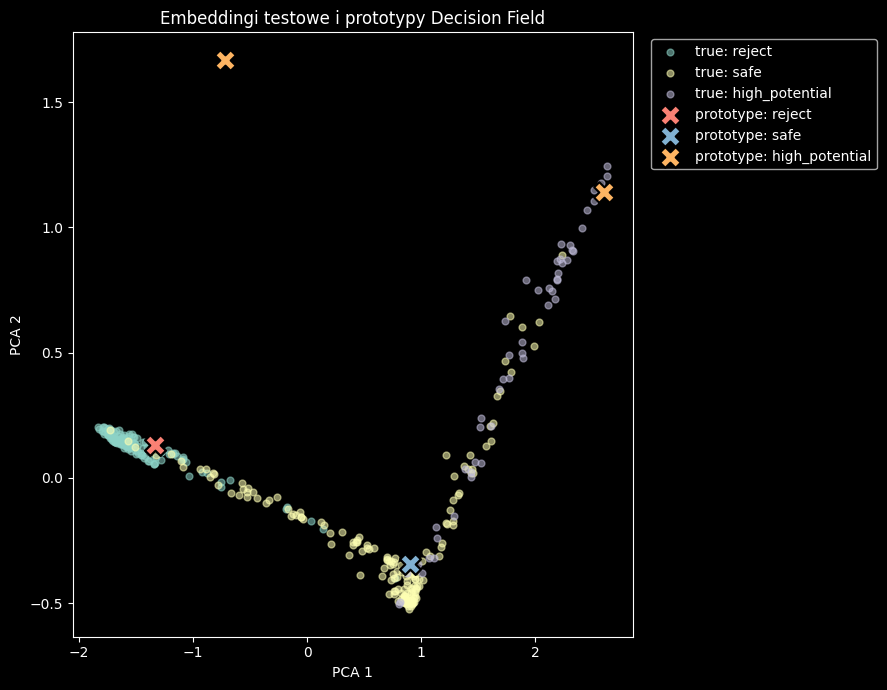

In [22]:
# PCA dla embeddingów i prototypów
pca = PCA(n_components=2, random_state=SEED)
z_2d = pca.fit_transform(test_z)

proto = final_model.field.prototypes.detach().cpu().numpy()      # [classes, proto_count, d]
proto_flat = proto.reshape(-1, proto.shape[-1])
proto_2d = pca.transform(proto_flat).reshape(proto.shape[0], proto.shape[1], 2)

# wykres punktów i prototypów
plt.figure(figsize=(9, 7))
for cls in range(3):
    mask = (test_y == cls)
    plt.scatter(
        z_2d[mask, 0], z_2d[mask, 1],
        s=24, alpha=0.55, label=f"true: {CLASS_NAMES[cls]}"
    )

for cls in range(3):
    plt.scatter(
        proto_2d[cls, :, 0], proto_2d[cls, :, 1],
        s=220, marker="X", edgecolors="black", linewidths=1.5,
        label=f"prototype: {CLASS_NAMES[cls]}"
    )

plt.title("Embeddingi testowe i prototypy Decision Field")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

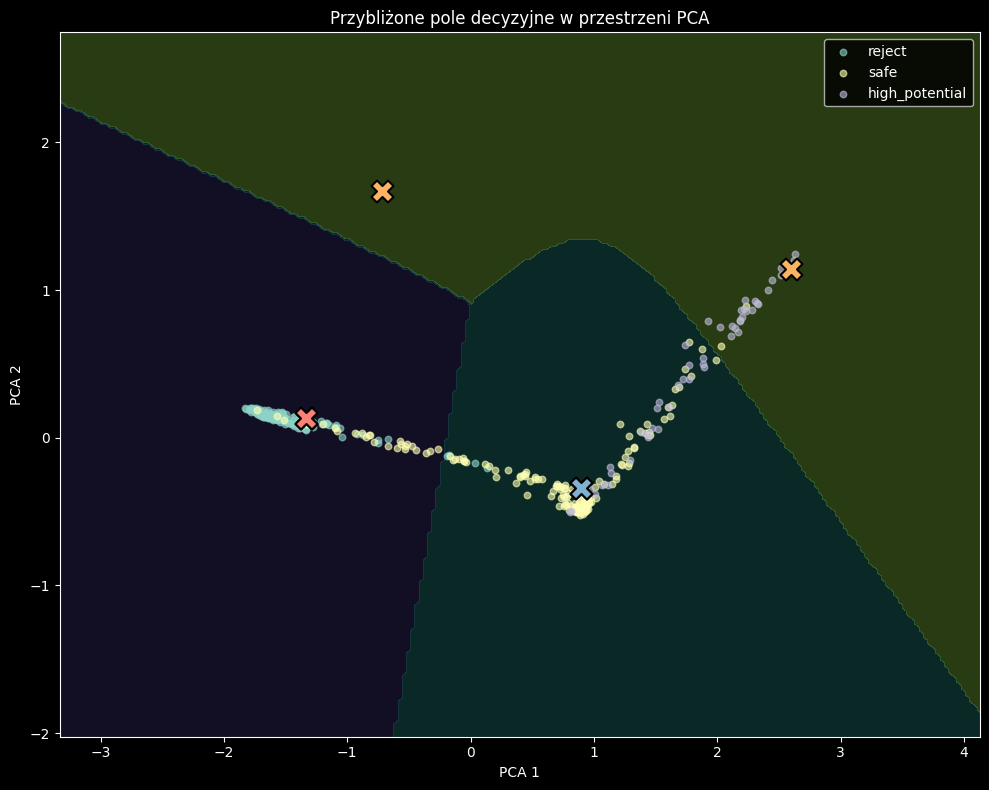

In [23]:
# Przybliżone pole decyzyjne w PCA-2D
def class_score_2d(points_2d, class_idx, proto_2d, temperature=1.0):
    # points_2d: [n,2]
    # proto_2d[class_idx]: [proto_count,2]
    points = points_2d[:, None, :]
    protos = proto_2d[class_idx][None, :, :]
    dist2 = ((points - protos) ** 2).sum(axis=-1)
    return np.exp(-dist2 / temperature).sum(axis=1)

x_min, x_max = z_2d[:, 0].min() - 1.5, z_2d[:, 0].max() + 1.5
y_min, y_max = z_2d[:, 1].min() - 1.5, z_2d[:, 1].max() + 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 220),
    np.linspace(y_min, y_max, 220)
)
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.column_stack([
    class_score_2d(grid, cls, proto_2d, temperature=best_genome["temperature"])
    for cls in range(3)
])
decision = scores.argmax(axis=1).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, decision, alpha=0.28, levels=np.arange(-0.5, 3.5, 1))

for cls in range(3):
    mask = (test_y == cls)
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=22, alpha=0.60, label=CLASS_NAMES[cls])

for cls in range(3):
    plt.scatter(
        proto_2d[cls, :, 0], proto_2d[cls, :, 1],
        s=250, marker="X", edgecolors="black", linewidths=1.5
    )

plt.title("Przybliżone pole decyzyjne w przestrzeni PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()

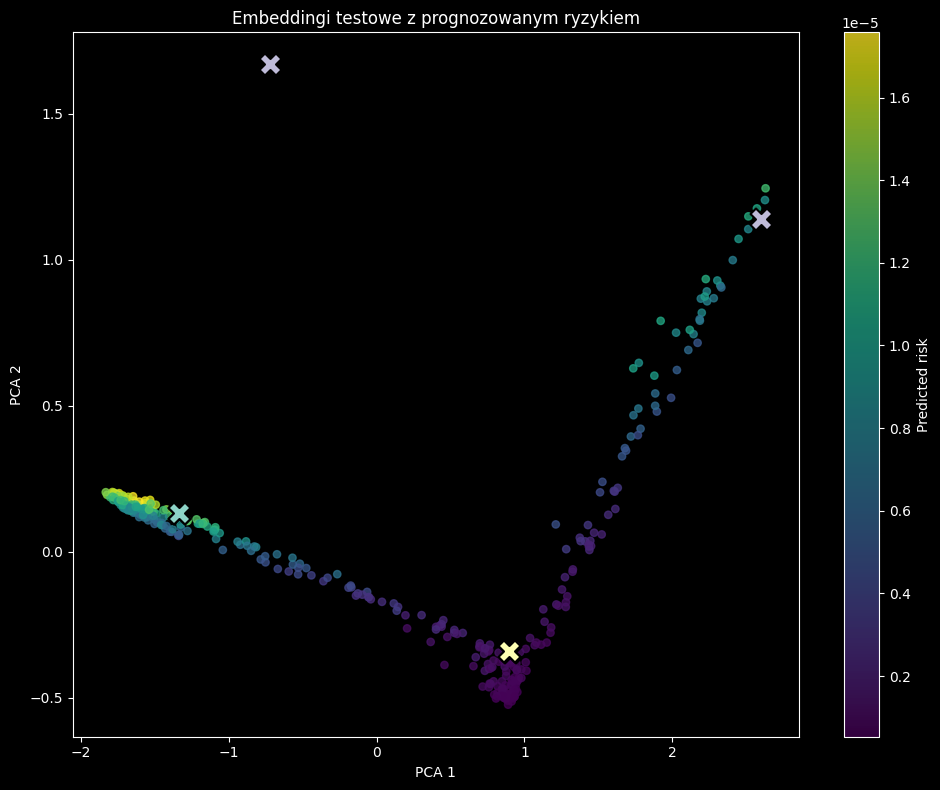

In [24]:
# wizualizacja ryzyka w przestrzeni 2D
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    z_2d[:, 0], z_2d[:, 1],
    c=test_risk, s=28, alpha=0.75
)
for cls in range(3):
    plt.scatter(
        proto_2d[cls, :, 0], proto_2d[cls, :, 1],
        s=250, marker="X", edgecolors="black", linewidths=1.5
    )

plt.colorbar(sc, label="Predicted risk")
plt.title("Embeddingi testowe z prognozowanym ryzykiem")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

## 9. Interpretacja dydaktyczna

Ten przykład dobrze pokazuje trzy idee:

### 1. Ewolucja
Nie stroi tylko jednej liczby, ale cały **styl modelu**:
- wymiar przestrzeni,
- liczbę warstw,
- temperaturę pola,
- liczbę prototypów,
- wagę ryzyka.

### 2. Transformer
Nie musi czytać tekstu.  
Może modelować **relacje między cechami decyzyjnymi**.

### 3. Decision Field
Model nie mówi tylko:
> „to jest klasa 2”

ale tworzy:
- bliskość do prototypów,
- napięcie między klasami,
- ryzyko decyzji,
- przestrzeń interpretacji.

To bardzo dobry most między klasycznym ML, deep learningiem i systemami wspomagania decyzji.

## 10. Ćwiczenia rozszerzające dla studentów

1. Zastąp PCA przez UMAP lub t-SNE.
2. Dodaj wielokryterialny fitness:
   - accuracy
   - F1
   - separation
   - stability
   - simplicity
3. Dodaj **novelty search** jako drugi komponent ewolucji.
4. Rozszerz problem o koszt błędu decyzyjnego.
5. Porównaj z baseline:
   - Logistic Regression
   - Random Forest
   - MLP
6. Niech ewolucja stroi także liczbę epok i scheduler.